# **Computer Vision with Deep Learning**

## Visual Recognition

## Lab2b - Transfer Learning for Image Classification

Adapted from `Sasank Chilamkurthy <https://chsasank.github.io>`_

2021 - 2026 Veronica Vilaplana - [GPI @ IDEAI](https://imatge.upc.edu/web/) Research group // [ETSETB – UPC.TelecosBCN](https://telecos.upc.edu/ca)

The goal of this assignment is to get hands on experience designing and trainind deep convolutional networks for image classification using PyTorch.
In this assignment you will use PyTorch, which is currently one of the most popular deep learning frameworks.

First, follow this tutorial.

These two major transfer learning scenarios look as follows:

-  **Finetuning the convnet**: Instead of random initializaion, we
   initialize the network with a pretrained network, like the one that is
   trained on imagenet 1000 dataset. Rest of the training looks as
   usual.
-  **ConvNet as fixed feature extractor**: Here, we will freeze the weights
   for all of the network except that of the final fully connected
   layer. This last fully connected layer is replaced with a new one
   with random weights and only this layer is trained.



# **Computer Vision with Deep Learning**

## Lab - Transfer Learning for Image Classification

**Author**: `Sasank Chilamkurthy <https://chsasank.github.io>`_

In this tutorial, you will learn how to train your network using transfer learning.

These two major transfer learning scenarios look as follows:

-  **Finetuning the convnet**: Instead of random initialization, we
   initialize the network with a pretrained network, like the one that is
   trained on imagenet 1000 dataset. Rest of the training looks as
   usual.
-  **ConvNet as fixed feature extractor**: Here, we will freeze the weights
   for all of the network except that of the final fully connected
   layer. This last fully connected layer is replaced with a new one
   with random weights and only this layer is trained.




In [3]:
# License: BSD
# Author: Sasank Chilamkurthy

from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms

%matplotlib inline
import matplotlib.pyplot as plt
import time
import os
import copy

plt.ion()   # interactive mode

###Load Data

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we're going to solve is to train a model to classify **ants** and **bees**.

We have about 120 training images each for ants and bees.
There are 75 validation images for each class. Usually, this is a very small dataset to generalize upon, if trained from scratch. Since we are using transfer learning, we should be able to generalize reasonably well.
This dataset is a very small subset of imagenet.



First, download from ATENEA the file hymenoptera_data.zip. Upload it to the Colab notebook using the menu on the left. Alternatively, you can copy the dataset to your Google Drive and mount gdrive.

In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

ValueError: mount failed

In [ ]:
!unzip hymenoptera_data.zip

We will use the ImageFolder Dataset class, which reads images from different folders, where each folder represents a different category. We will use torchvision.transforms to preprocess our data.

In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
       'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),       # Convert the image to a tensor with pixels in the range [0, 1]
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),       # Resize the short side of the image to 150 keeping aspect ratio
        transforms.CenterCrop(224),   # Crop a square in the center of the image
        transforms.ToTensor(),        # Convert the image to a tensor with pixels in the range [0, 1]
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Loading datasets with Pytorch ImageFolder
data_dir = 'hymenoptera_data'

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(class_names)

###Visualize a few images

Let's visualize a few training images so as to understand the data
augmentations.



In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

###Training the model

Now, let's write a general function to train a model. Here, we will
illustrate:

-  Scheduling the learning rate
-  Saving the best model

In the following, parameter ``scheduler`` is an LR scheduler object from
``torch.optim.lr_scheduler``.



In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                scheduler.step()
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

###Visualizing the model predictions

Generic function to display predictions for a few images




In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Option 1: Finetuning the convnet

Load a pretrained model and reset final fully connected layer.




In [ ]:
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

###Train and evaluate

It should take around 15-25 min on CPU. On GPU though, it takes less than a
minute.




In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

In [ ]:
visualize_model(model_ft)

#Option 2: ConvNet as fixed feature extractor

Here, we need to freeze all the network except the final layer. We need
to set ``requires_grad == False`` to freeze the parameters so that the
gradients are not computed in ``backward()``.

You can read more about this in the documentation
`here <http://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward>`__.




In [ ]:
model_conv = torchvision.models.resnet18(pretrained=True)
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opoosed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

###Train and evaluate

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don't need to be computed for most of the
network. However, forward does need to be computed.




In [ ]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

#Tasks

You will use a model pre-trained on ImageNet for classifying the Caltech-UCSD Birds dataset (200 categories of birds, 3000 images in train and 3033 images in test).

0. Load and unzip the dataset (file CaltechBirds.zip)

1. Split the 'train' set into 'train' and 'validation' splits. In the following experiments use the train and validation splits to train and select the best model and then evaluate on the test split (you will need to modify the previous code).

2. Use the ResNet18 model pretrained on ImageNet with the parameters used in the previous example. Use the two approaches (fixed feature extractor or fine-tuning the model)

3. Vary hyperparameters to improve the performance

4. Compute and show additional metrics

5. Repeat using a different pre-trained model available in Pytorch
https://pytorch.org/vision/stable/models.html


In [ ]:
!unzip CaltechBirds.zipN

# 1) Preparar datasets y split train->train/val

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import os

In [2]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

def load_dataset(data_dir):
    return datasets.ImageFolder(
        os.path.join(data_dir, "train"),
        transform=data_transforms['train']
    )

def split_dataset(dataset, val_ratio=0.2, seed=42):
    torch.manual_seed(seed)

    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size

    return random_split(dataset, [train_size, val_size])

def create_dataloaders(train_ds, val_ds, batch_size=32):
    return {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        'val': DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    }

def load_test(data_dir):
    return datasets.ImageFolder(
        os.path.join(data_dir, "test"),
        transform=data_transforms['val']
    )

In [5]:
data_dir = "CaltechBirds"

full_dataset = load_dataset(data_dir)
class_names = full_dataset.classes
train_ds, val_ds = split_dataset(full_dataset)

dataloaders = create_dataloaders(train_ds, val_ds)

test_dataset = load_test(data_dir)
test_loader = DataLoader(test_dataset, batch_size=32)

# 2) Configurar `ResNet18` (fine-tune y feature-extractor)

In [6]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

In [7]:
def build_resnet18(num_classes, feature_extract=False, device=None):
    model = models.resnet18(pretrained=True)

    # freeze if feature extractor
    if feature_extract:
        for param in model.parameters():
            param.requires_grad = False

    # replace classifier
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    if device:
        model = model.to(device)

    return model

def build_optimizer_and_scheduler(model, lr=0.001, momentum=0.9):
    params = filter(lambda p: p.requires_grad, model.parameters())

    optimizer = optim.SGD(params, lr=lr, momentum=momentum)

    scheduler = lr_scheduler.StepLR(
        optimizer,
        step_size=7,
        gamma=0.1
    )

    return optimizer, scheduler

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Feature Extractor
model_fe = build_resnet18(num_classes=200, feature_extract=True, device=device)
optimizer, scheduler = build_optimizer_and_scheduler(model_fe)

# Fine Tuning
model_ft = build_resnet18(num_classes=200, feature_extract=False, device=device)
optimizer, scheduler = build_optimizer_and_scheduler(model_ft)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# 3) Bucle de entrenamiento reutilizable y evaluación con métricas adicionales

In [19]:
import time
import copy
import torch
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
def train_model_with_history(
    model, dataloaders, criterion, optimizer, scheduler,
    device, num_epochs=25
):

    since = time.time()

    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    model = model.to(device)

    for epoch in range(num_epochs):

        print(f"Epoch {epoch}/{num_epochs-1}")
        print("-" * 20)

        for phase in ['train', 'val']:

            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum()

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = copy.deepcopy(model.state_dict())

        scheduler.step()
        print()

    model.load_state_dict(best_wts)

    print(f"Best val Acc: {best_acc:.4f}")

    return model, history

In [20]:
def evaluate_model(model, dataloader, device, class_names=None):

    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro'
    )

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "report": report,
        "confusion_matrix": cm
    }

In [13]:
def plot_confusion_matrix(cm, class_names):

    plt.figure(figsize=(10, 8))

    sns.heatmap(cm, annot=False, cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")

    plt.show()

# A) Feature Extractor

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_fe = build_resnet18(
    num_classes=200,
    feature_extract=True,
    device=device
)

optimizer_fe, scheduler_fe = build_optimizer_and_scheduler(model_fe)

criterion = nn.CrossEntropyLoss()

model_fe, history_fe = train_model_with_history(
    model_fe,
    dataloaders,
    criterion,
    optimizer_fe,
    scheduler_fe,
    device,
    num_epochs=10
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 0/9
--------------------
train Loss: 5.4261 Acc: 0.0058
val Loss: 5.2861 Acc: 0.0117

Epoch 1/9
--------------------
train Loss: 5.1234 Acc: 0.0246
val Loss: 5.0996 Acc: 0.0400

Epoch 2/9
--------------------
train Loss: 4.8854 Acc: 0.0713
val Loss: 4.9373 Acc: 0.0600

Epoch 3/9
--------------------
train Loss: 4.6644 Acc: 0.1292
val Loss: 4.7908 Acc: 0.0833

Epoch 4/9
--------------------
train Loss: 4.4652 Acc: 0.1850
val Loss: 4.6315 Acc: 0.1233

Epoch 5/9
--------------------
train Loss: 4.2626 Acc: 0.2621
val Loss: 4.4944 Acc: 0.1417

Epoch 6/9
--------------------
train Loss: 4.0755 Acc: 0.3192
val Loss: 4.3599 Acc: 0.1567

Epoch 7/9
--------------------
train Loss: 3.9156 Acc: 0.3796
val Loss: 4.3326 Acc: 0.1633

Epoch 8/9
--------------------
train Loss: 3.8996 Acc: 0.3842
val Loss: 4.3305 Acc: 0.1583

Epoch 9/9
--------------------
train Loss: 3.8739 Acc: 0.4075
val Loss: 4.3216 Acc: 0.1617

Best val Acc: 0.1633


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.175
0.14661043531631765
                                    precision    recall  f1-score   support

        001.Black_footed_Albatross       0.29      1.00      0.44         2
              002.Laysan_Albatross       0.25      0.50      0.33         2
               003.Sooty_Albatross       0.00      0.00      0.00         4
             004.Groove_billed_Ani       0.00      0.00      0.00         3
                005.Crested_Auklet       0.00      0.00      0.00         3
                  006.Least_Auklet       0.33      1.00      0.50         2
               007.Parakeet_Auklet       0.00      0.00      0.00         4
             008.Rhinoceros_Auklet       0.00      0.00      0.00         6
              009.Brewer_Blackbird       0.00      0.00      0.00         2
          010.Red_winged_Blackbird       0.00      0.00      0.00         3
               011.Rusty_Blackbird       0.00      0.00      0.00         2
       012.Yellow_headed_Blackbird       0.00      0.00      

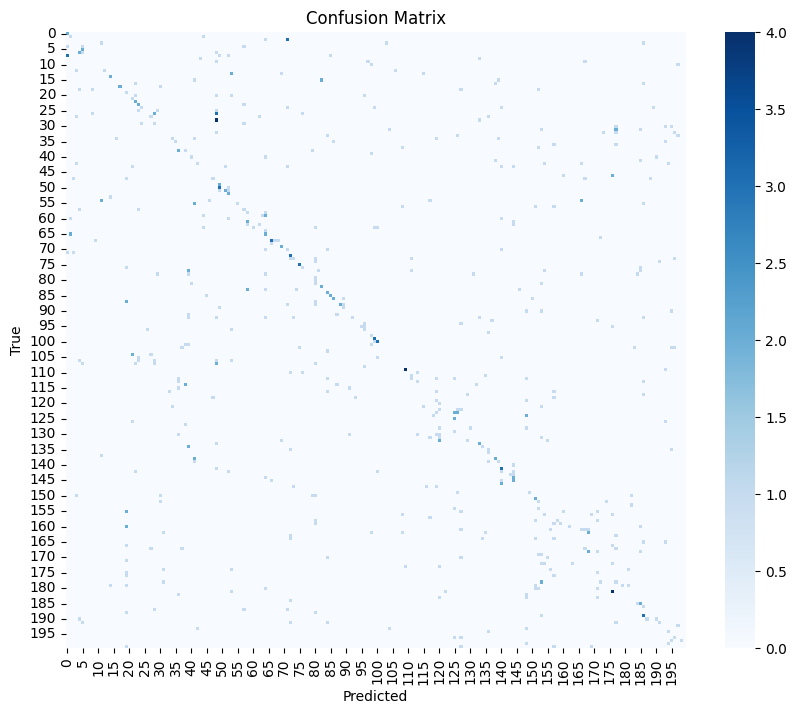

In [23]:
metrics_fe = evaluate_model(model_fe, dataloaders['val'], device, class_names)

print(metrics_fe["accuracy"])
print(metrics_fe["f1"])
print(metrics_fe["report"])
plot_confusion_matrix(metrics_fe["confusion_matrix"], class_names)

# A) Fine Tuning

In [16]:
model_ft = build_resnet18(
    num_classes=200,
    feature_extract=False,
    device=device
)

optimizer_ft, scheduler_ft = build_optimizer_and_scheduler(model_ft)

model_ft, history_ft = train_model_with_history(
    model_ft,
    dataloaders,
    criterion,
    optimizer_ft,
    scheduler_ft,
    device,
    num_epochs=10
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 0/9
--------------------
train Loss: 5.3439 Acc: 0.0121
val Loss: 5.1056 Acc: 0.0317

Epoch 1/9
--------------------
train Loss: 4.7775 Acc: 0.0888
val Loss: 4.7260 Acc: 0.0917

Epoch 2/9
--------------------
train Loss: 4.2546 Acc: 0.2571
val Loss: 4.3541 Acc: 0.1417

Epoch 3/9
--------------------
train Loss: 3.7680 Acc: 0.3942
val Loss: 3.9893 Acc: 0.2033

Epoch 4/9
--------------------
train Loss: 3.3306 Acc: 0.4917
val Loss: 3.7007 Acc: 0.2333

Epoch 5/9
--------------------
train Loss: 2.9548 Acc: 0.5871
val Loss: 3.4149 Acc: 0.2900

Epoch 6/9
--------------------
train Loss: 2.6127 Acc: 0.6679
val Loss: 3.2044 Acc: 0.3317

Epoch 7/9
--------------------
train Loss: 2.3366 Acc: 0.7646
val Loss: 3.1707 Acc: 0.3500

Epoch 8/9
--------------------
train Loss: 2.3075 Acc: 0.7654
val Loss: 3.1655 Acc: 0.3367

Epoch 9/9
--------------------
train Loss: 2.2827 Acc: 0.7738
val Loss: 3.1306 Acc: 0.3417

Best val Acc: 0.3500


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.34
0.3152608543417367
                                    precision    recall  f1-score   support

        001.Black_footed_Albatross       0.50      1.00      0.67         2
              002.Laysan_Albatross       0.40      1.00      0.57         2
               003.Sooty_Albatross       0.00      0.00      0.00         4
             004.Groove_billed_Ani       0.50      0.33      0.40         3
                005.Crested_Auklet       0.00      0.00      0.00         3
                  006.Least_Auklet       0.33      1.00      0.50         2
               007.Parakeet_Auklet       0.00      0.00      0.00         4
             008.Rhinoceros_Auklet       0.50      0.33      0.40         6
              009.Brewer_Blackbird       0.00      0.00      0.00         2
          010.Red_winged_Blackbird       0.50      0.33      0.40         3
               011.Rusty_Blackbird       0.00      0.00      0.00         2
       012.Yellow_headed_Blackbird       0.00      0.00      0.

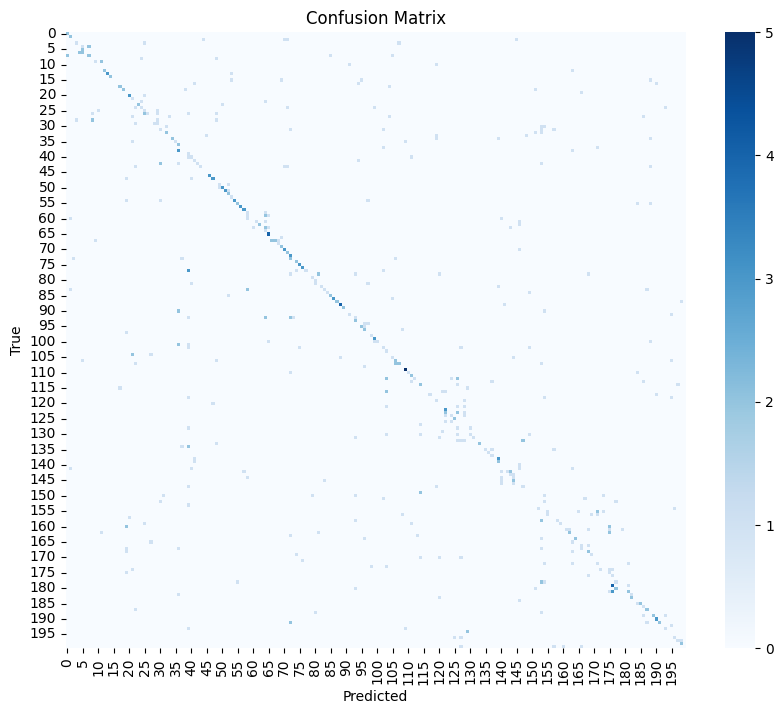

In [26]:
metrics_ft = evaluate_model(model_ft, dataloaders['val'], device, class_names)

print(metrics_ft["accuracy"])
print(metrics_ft["f1"])
print(metrics_ft["report"])
plot_confusion_matrix(metrics_ft["confusion_matrix"], class_names)

# 4) Busqueda de hiperparámetros

In [32]:
def run_experiment(cfg, data_dir, data_transforms, device, num_epochs=10):

    print(f"\n=== Config: {cfg} ===")

    # Dataset (TU PIPELINE REAL)
    full_dataset = load_dataset(data_dir)
    class_names = full_dataset.classes

    train_ds, val_ds = split_dataset(full_dataset)

    dataloaders = create_dataloaders(
        train_ds,
        val_ds,
        batch_size=cfg['batch_size']
    )

    num_classes = len(class_names)

    # Model (TU FUNCIÓN REAL)
    model = build_resnet18(
        num_classes=num_classes,
        feature_extract=cfg['feature_extract'],
        device=device
    )

    optimizer, scheduler = build_optimizer_and_scheduler(
        model,
        lr=cfg['lr'],
        momentum=cfg.get('momentum', 0.9)
    )

    criterion = nn.CrossEntropyLoss()

    # Train
    model, history = train_model_with_history(
        model,
        dataloaders,
        criterion,
        optimizer,
        scheduler,
        device,
        num_epochs=num_epochs
    )

    # Eval (TU FUNCIÓN REAL)
    eval_results = evaluate_model(
        model,
        dataloaders['val'],
        device,
        class_names=class_names
    )

    report = eval_results["report"]
    cm = eval_results["confusion_matrix"]

    return {
        "config": cfg,
        "history": history,
        "report": report,
        "confusion_matrix": cm
    }

In [28]:
def hyperparameter_search(grid, data_dir, data_transforms, device, num_epochs=10):

    results = []

    for cfg in grid:
        result = run_experiment(
            cfg,
            data_dir,
            data_transforms,
            device,
            num_epochs=num_epochs
        )
        results.append(result)

    return results

In [33]:
grid = [
    {
        "lr": 0.001,
        "batch_size": 32,
        "feature_extract": True
    },
    {
        "lr": 0.001,
        "batch_size": 32,
        "feature_extract": False
    },
    {
        "lr": 0.0005,
        "batch_size": 64,
        "feature_extract": False
    }
]

In [34]:
results = hyperparameter_search(
    grid=grid,
    data_dir=data_dir,
    data_transforms=data_transforms,
    device=device,
    num_epochs=10
)


=== Config: {'lr': 0.001, 'batch_size': 32, 'feature_extract': True} ===
Epoch 0/9
--------------------


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


train Loss: 5.4047 Acc: 0.0083
val Loss: 5.3068 Acc: 0.0217

Epoch 1/9
--------------------
train Loss: 5.1150 Acc: 0.0271
val Loss: 5.1200 Acc: 0.0417

Epoch 2/9
--------------------
train Loss: 4.8803 Acc: 0.0663
val Loss: 4.9651 Acc: 0.0633

Epoch 3/9
--------------------
train Loss: 4.6592 Acc: 0.1254
val Loss: 4.7901 Acc: 0.0817

Epoch 4/9
--------------------
train Loss: 4.4447 Acc: 0.1846
val Loss: 4.6270 Acc: 0.1183

Epoch 5/9
--------------------
train Loss: 4.2530 Acc: 0.2413
val Loss: 4.4981 Acc: 0.1467

Epoch 6/9
--------------------
train Loss: 4.0712 Acc: 0.2921
val Loss: 4.3771 Acc: 0.1550

Epoch 7/9
--------------------
train Loss: 3.9209 Acc: 0.3633
val Loss: 4.3640 Acc: 0.1600

Epoch 8/9
--------------------
train Loss: 3.8954 Acc: 0.3771
val Loss: 4.3392 Acc: 0.1583

Epoch 9/9
--------------------
train Loss: 3.8793 Acc: 0.3867
val Loss: 4.3327 Acc: 0.1667

Best val Acc: 0.1667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are depr


=== Config: {'lr': 0.001, 'batch_size': 32, 'feature_extract': False} ===
Epoch 0/9
--------------------
train Loss: 5.3460 Acc: 0.0117
val Loss: 5.1591 Acc: 0.0283

Epoch 1/9
--------------------
train Loss: 4.7612 Acc: 0.0979
val Loss: 4.7785 Acc: 0.0900

Epoch 2/9
--------------------
train Loss: 4.2333 Acc: 0.2579
val Loss: 4.4213 Acc: 0.1267

Epoch 3/9
--------------------
train Loss: 3.7494 Acc: 0.3783
val Loss: 4.0501 Acc: 0.1800

Epoch 4/9
--------------------
train Loss: 3.3038 Acc: 0.5029
val Loss: 3.7394 Acc: 0.2200

Epoch 5/9
--------------------
train Loss: 2.9346 Acc: 0.5913
val Loss: 3.4845 Acc: 0.2617

Epoch 6/9
--------------------
train Loss: 2.5844 Acc: 0.6633
val Loss: 3.2650 Acc: 0.3133

Epoch 7/9
--------------------
train Loss: 2.3143 Acc: 0.7638
val Loss: 3.2592 Acc: 0.3067

Epoch 8/9
--------------------
train Loss: 2.2785 Acc: 0.7696
val Loss: 3.2312 Acc: 0.3100

Epoch 9/9
--------------------
train Loss: 2.2608 Acc: 0.7758
val Loss: 3.2034 Acc: 0.3333

Best 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are depr


=== Config: {'lr': 0.0005, 'batch_size': 64, 'feature_extract': False} ===
Epoch 0/9
--------------------
train Loss: 5.4697 Acc: 0.0088
val Loss: 5.4217 Acc: 0.0117

Epoch 1/9
--------------------
train Loss: 5.2698 Acc: 0.0163
val Loss: 5.3027 Acc: 0.0133

Epoch 2/9
--------------------
train Loss: 5.0918 Acc: 0.0288
val Loss: 5.2165 Acc: 0.0250

Epoch 3/9
--------------------
train Loss: 4.9318 Acc: 0.0608
val Loss: 5.1065 Acc: 0.0367

Epoch 4/9
--------------------
train Loss: 4.7758 Acc: 0.1029
val Loss: 5.0091 Acc: 0.0417

Epoch 5/9
--------------------
train Loss: 4.6307 Acc: 0.1517
val Loss: 4.9237 Acc: 0.0617

Epoch 6/9
--------------------
train Loss: 4.4833 Acc: 0.2004
val Loss: 4.8354 Acc: 0.0800

Epoch 7/9
--------------------
train Loss: 4.3806 Acc: 0.2388
val Loss: 4.8301 Acc: 0.0800

Epoch 8/9
--------------------
train Loss: 4.3650 Acc: 0.2542
val Loss: 4.8114 Acc: 0.0817

Epoch 9/9
--------------------
train Loss: 4.3503 Acc: 0.2500
val Loss: 4.8035 Acc: 0.0783

Best

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
import pandas as pd

summary = []

for r in results:
    summary.append({
        "lr": r["config"]["lr"],
        "batch_size": r["config"]["batch_size"],
        "feature_extract": r["config"]["feature_extract"],
        "report": r["report"]
    })

df = pd.DataFrame(summary)
df

,lr,batch_size,feature_extract,report
0,0.0010,32,True,precision ...
1,0.0010,32,False,precision ...
2,0.0005,64,False,precision ...


# 5) New Model

In [35]:
import torchvision.models as models
import torch.nn as nn

def build_model(model_name, num_classes, feature_extract=False, device=None):

    if model_name == "resnet18":
        model = models.resnet18(weights="IMAGENET1K_V1")

    elif model_name == "resnet50":
        model = models.resnet50(weights="IMAGENET1K_V1")

    elif model_name == "mobilenet_v3":
        model = models.mobilenet_v3_large(weights="IMAGENET1K_V1")

    else:
        raise ValueError("Model not supported")

    # freeze if feature extractor
    if feature_extract:
        for p in model.parameters():
            p.requires_grad = False

    # replace classifier depending on architecture
    if "resnet" in model_name:
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif "mobilenet" in model_name:
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)

    if device:
        model = model.to(device)

    return model

In [36]:
def run_experiment(cfg, model_name, data_dir, device, num_epochs=10):

    # dataset
    full_dataset = load_dataset(data_dir)
    class_names = full_dataset.classes

    train_ds, val_ds = split_dataset(full_dataset)

    dataloaders = create_dataloaders(
        train_ds,
        val_ds,
        batch_size=cfg["batch_size"]
    )

    num_classes = len(class_names)

    # model
    model = build_model(
        model_name=model_name,
        num_classes=num_classes,
        feature_extract=cfg["feature_extract"],
        device=device
    )

    optimizer, scheduler = build_optimizer_and_scheduler(
        model,
        lr=cfg["lr"],
        momentum=cfg.get("momentum", 0.9)
    )

    criterion = nn.CrossEntropyLoss()

    # train
    model, history = train_model_with_history(
        model,
        dataloaders,
        criterion,
        optimizer,
        scheduler,
        device,
        num_epochs=num_epochs
    )

    # eval
    metrics = evaluate_model(
        model,
        dataloaders["val"],
        device,
        class_names
    )

    return {
        "config": cfg,
        "model": model_name,
        "history": history,
        "metrics": metrics
    }

In [37]:
def run_grid(grid, model_name, data_dir, device):

    results = []

    for cfg in grid:
        print("\n========================")
        print("Model:", model_name)
        print("Config:", cfg)

        res = run_experiment(
            cfg=cfg,
            model_name=model_name,
            data_dir=data_dir,
            device=device,
            num_epochs=10
        )

        results.append(res)

    return results

In [40]:
def summarize_results(results):

    summary = []

    for r in results:
        summary.append({
            "model": r["model"],
            "lr": r["config"]["lr"],
            "batch": r["config"]["batch_size"],
            "feature_extract": r["config"]["feature_extract"],
            "acc": r["metrics"]["accuracy"],
            "f1": r["metrics"]["f1"]
        })

    import pandas as pd
    df = pd.DataFrame(summary)
    return df.sort_values("acc", ascending=False)

In [39]:
grid = [
    {"lr": 0.001, "batch_size": 32, "feature_extract": True},
    {"lr": 0.001, "batch_size": 32, "feature_extract": False},
    {"lr": 0.0005, "batch_size": 64, "feature_extract": False},
]

In [ ]:
resnet_results = run_grid(grid, "resnet18", data_dir, device)
df_resnet = summarize_results(resnet_results)
df_resnet

In [41]:
mobilenet_results = run_grid(grid, "mobilenet_v3", data_dir, device)
df_mobilenet = summarize_results(mobilenet_results)
df_mobilenet


Model: mobilenet_v3
Config: {'lr': 0.001, 'batch_size': 32, 'feature_extract': True}
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 91.0MB/s]


Epoch 0/9
--------------------
train Loss: 5.3148 Acc: 0.0083
val Loss: 5.2149 Acc: 0.0183

Epoch 1/9
--------------------
train Loss: 5.1085 Acc: 0.0354
val Loss: 5.0585 Acc: 0.0383

Epoch 2/9
--------------------
train Loss: 4.8947 Acc: 0.0967
val Loss: 4.9364 Acc: 0.0650

Epoch 3/9
--------------------
train Loss: 4.6896 Acc: 0.1729
val Loss: 4.8298 Acc: 0.0883

Epoch 4/9
--------------------
train Loss: 4.4882 Acc: 0.2704
val Loss: 4.7310 Acc: 0.1200

Epoch 5/9
--------------------
train Loss: 4.3118 Acc: 0.3329
val Loss: 4.6302 Acc: 0.1283

Epoch 6/9
--------------------
train Loss: 4.1309 Acc: 0.4008
val Loss: 4.5308 Acc: 0.1583

Epoch 7/9
--------------------
train Loss: 4.0125 Acc: 0.4542
val Loss: 4.5276 Acc: 0.1550

Epoch 8/9
--------------------
train Loss: 3.9977 Acc: 0.4588
val Loss: 4.5141 Acc: 0.1617

Epoch 9/9
--------------------
train Loss: 3.9827 Acc: 0.4642
val Loss: 4.5024 Acc: 0.1633

Best val Acc: 0.1633


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ValueError: Number of classes, 198, does not match size of target_names, 200. Try specifying the labels parameter

Durante la fase de evaluación del modelo con el conjunto de validación, se ha producido un error en la generación del classification_report de Scikit-learn. El error indica una discrepancia entre el número de clases presentes en el dataset y el número de clases esperadas según los nombres de clase proporcionados.

Este problema se debe a la forma en la que se ha realizado la partición del conjunto de datos original mediante un split aleatorio (random_split). En este tipo de particionado no estratificado, no se garantiza que todas las clases del dataset aparezcan representadas en cada subconjunto (train/validation). Como consecuencia, en este caso concreto, algunas clases del conjunto completo (200 clases en total) no están presentes en el conjunto de validación (por ejemplo, únicamente aparecen 198 clases en las predicciones reales).

Esto provoca una inconsistencia en las métricas de evaluación, ya que classification_report espera que el número de clases en y_true y y_pred coincida con el número de etiquetas proporcionadas en target_names.